# 02 — EDA & Wawasan Visual: *Mengapa* keputusan desain ini?
## Construction Safety Helmet — YOLO26

> ℹ️ **Opsional — tidak wajib untuk training.** Notebook ini untuk *memahami* dataset. Hanya sel §18 yang menulis artefak ke `runs/eda/` (CSV/laporan), dan itu pun tidak dibutuhkan oleh training. Kamu bisa langsung ke `03_train`.

Notebook ini menggabungkan EDA dataset dengan **banyak visualisasi yang menjelaskan 'kenapa'** keputusan proyek diambil. Format tiap bagian:
**❓ Pertanyaan → 📊 Visual → 💡 Mengapa ini penting.** Semua angka dihitung langsung dari `dataset/` (konsisten dengan `src/eda.py`).

## Setup

In [2]:
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: d:\ML\test-code\construction-safety-helmet-yolo26


## 0. Bangun satu tabel besar dari semua label
Satu baris `df` = satu bounding box. Sekalian menghitung **baris label nyasar** (bukan 5 kolom — mis. label segmentasi) yang otomatis dibuang pipeline.

In [3]:
import eda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
from PIL import Image

plt.rcParams["figure.dpi"] = 110
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
CLASS_COLORS = {0: "#4c72b0", 1: "#c44e52", 2: "#55a868"}  # Helmet / No-Helmet / Person
SMALL, MED = eda.SMALL_AREA_THR, eda.MEDIUM_AREA_THR

data, class_names, nc, root = eda.load_dataset_config("dataset/data.yaml")
splits = eda.resolve_splits(root, data)
COLORS = [CLASS_COLORS[i] for i in range(nc)]

records, path_map, density = [], {}, []
malformed_by_split, no_anno = {}, 0
for split, (images_dir, labels_dir) in splits.items():
    counts, malformed = {}, 0
    for lbl in labels_dir.glob("*.txt"):
        n = 0
        try:
            text = lbl.read_text(encoding="utf-8", errors="replace")
        except Exception:
            continue
        for line in text.splitlines():
            line = line.strip()
            if not line:
                continue
            p = line.split()
            ok = len(p) == 5
            if ok:
                try:
                    cid = int(p[0]); x, y, w, h = map(float, p[1:])
                except ValueError:
                    ok = False
            if not ok or cid < 0 or cid >= nc or w <= 0 or h <= 0:
                malformed += 1
                continue
            records.append((split, lbl.stem, cid, x, y, w, h)); n += 1
        counts[lbl.stem] = n
    malformed_by_split[split] = malformed
    for img in images_dir.iterdir():
        if img.suffix.lower() in IMAGE_EXTS:
            path_map[(split, img.stem)] = img
            c = counts.get(img.stem, 0); density.append((split, c))
            if c == 0:
                no_anno += 1

df = pd.DataFrame(records, columns=["split", "stem", "class_id", "cx", "cy", "w", "h"])
df["area"] = df["w"] * df["h"]
df["aspect"] = df["w"] / df["h"]
df["class"] = df["class_id"].map({i: class_names[i] for i in range(nc)})
df["edge"] = ((df.cx - df.w/2 <= 0.01) | (df.cy - df.h/2 <= 0.01) |
              (df.cx + df.w/2 >= 0.99) | (df.cy + df.h/2 >= 0.99))
df["tiny"] = df.area < 5e-4
dens = pd.DataFrame(density, columns=["split", "n_boxes"])

print(f"kelas         : {class_names}")
print(f"total bbox    : {len(df):,}")
print(f"total gambar  : {len(density):,}  (tanpa anotasi: {no_anno:,})")
print(f"label nyasar  : {malformed_by_split}")
df.head()

kelas         : ['Helmet', 'No-Helmet', 'Person']
total bbox    : 58,368
total gambar  : 19,456  (tanpa anotasi: 2)
label nyasar  : {'train': 2, 'valid': 1, 'test': 0}


,split,stem,class_id,cx,cy,w,h,area,aspect,class,edge,tiny
0,train,-1079-_png_jpg.rf.M10vUajhbB46CIFUGwZs,2,0.101562,0.625781,0.073438,0.179688,0.013196,0.408696,Person,False,False
1,train,-1079-_png_jpg.rf.M10vUajhbB46CIFUGwZs,2,0.653125,0.652344,0.112500,0.325000,0.036563,0.346154,Person,False,False
2,train,-1079-_png_jpg.rf.M10vUajhbB46CIFUGwZs,2,0.813281,0.547656,0.014063,0.034375,0.000483,0.409091,Person,False,True
3,train,-1079-_png_jpg.rf.M10vUajhbB46CIFUGwZs,2,0.861719,0.547656,0.017188,0.039062,0.000671,0.440000,Person,False,False
4,train,-1079-_png_jpg.rf.M10vUajhbB46CIFUGwZs,2,0.925000,0.549219,0.020313,0.045312,0.000920,0.448276,Person,False,False


## 1. Distribusi kelas — *kenapa* `No-Helmet` jadi tantangan utama
**💡** Kelas minoritas → recall rendah. Untuk K3 justru **`No-Helmet`** yang paling penting terdeteksi, jadi imbalance di sini berisiko langsung.

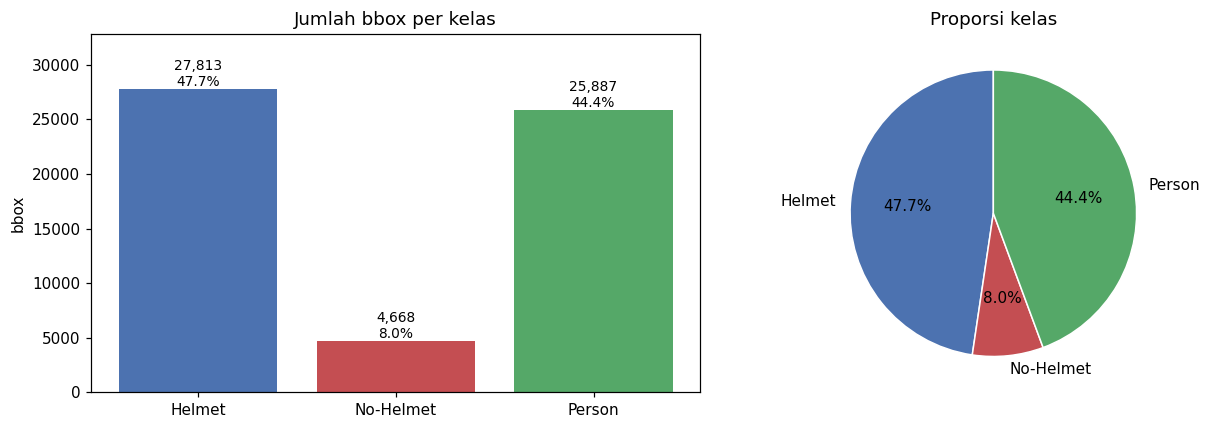

minoritas: 'No-Helmet' (4,668, 8.0%) | rasio maks/min = 6.0x


In [4]:
counts = df["class"].value_counts().reindex(class_names)
pct = 100 * counts / counts.sum()
ratio = counts.max() / counts.min() if counts.min() else float("inf")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
bars = ax[0].bar(class_names, counts.values, color=COLORS)
for b, v, p in zip(bars, counts.values, pct.values):
    ax[0].text(b.get_x()+b.get_width()/2, v, f"{v:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax[0].set_title("Jumlah bbox per kelas"); ax[0].set_ylabel("bbox"); ax[0].margins(y=0.18)
ax[1].pie(counts.values, labels=class_names, colors=COLORS, autopct="%1.1f%%", startangle=90,
          wedgeprops={"edgecolor": "white"}); ax[1].set_title("Proporsi kelas")
plt.tight_layout(); plt.show()
print(f"minoritas: '{counts.idxmin()}' ({counts.min():,}, {pct.min():.1f}%) | rasio maks/min = {ratio:.1f}x")

## 2. Komposisi kelas per split — *kenapa* split dianggap adil
**💡** Kalau distribusi train ≠ test, penurunan metrik test bisa karena **pergeseran distribusi**, bukan overfitting. Memvalidasi asumsi 'val/test representatif'.

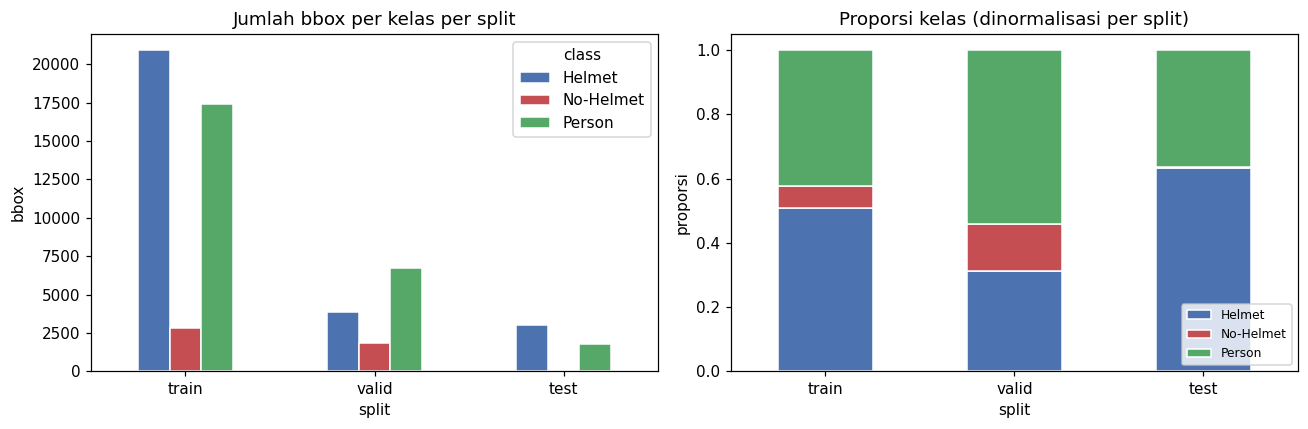

class,Helmet,No-Helmet,Person
split,,,
train,0.508,0.068,0.424
valid,0.311,0.149,0.540
test,0.633,0.003,0.365


In [5]:
ct = pd.crosstab(df["split"], df["class"]).reindex(index=["train","valid","test"], columns=class_names)
prop = ct.div(ct.sum(axis=1), axis=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ct.plot.bar(ax=ax[0], color=COLORS, edgecolor="white"); ax[0].set_title("Jumlah bbox per kelas per split")
ax[0].set_ylabel("bbox"); ax[0].tick_params(axis="x", rotation=0)
prop.plot.bar(stacked=True, ax=ax[1], color=COLORS, edgecolor="white")
ax[1].set_title("Proporsi kelas (dinormalisasi per split)"); ax[1].set_ylabel("proporsi")
ax[1].tick_params(axis="x", rotation=0); ax[1].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show(); display(prop.round(3))

## 3. Ukuran objek — *kenapa* `imgsz=640` & penanganan objek kecil
**💡** Banyak objek **kecil** → menurunkan `imgsz` menghapus detail → objek hilang. Justifikasi tetap di 640.

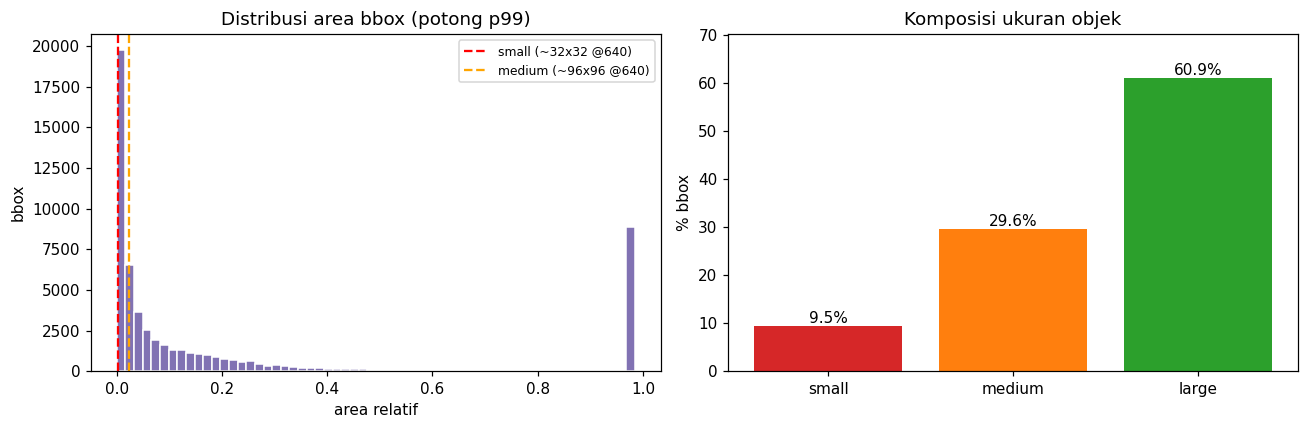

small=9.5%  medium=29.6%  large=60.9%  => pertahankan imgsz=640


In [6]:
area = df["area"].values
fs = (area < SMALL).mean(); fm = ((area>=SMALL)&(area<MED)).mean(); fl = (area>=MED).mean()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.clip(area, 0, np.percentile(area, 99)), bins=60, color="#8172b3", edgecolor="white")
ax[0].axvline(SMALL, color="red", ls="--", label="small (~32x32 @640)")
ax[0].axvline(MED, color="orange", ls="--", label="medium (~96x96 @640)")
ax[0].set_title("Distribusi area bbox (potong p99)"); ax[0].set_xlabel("area relatif"); ax[0].set_ylabel("bbox"); ax[0].legend(fontsize=8)
ax[1].bar(["small","medium","large"], [fs*100, fm*100, fl*100], color=["#d62728","#ff7f0e","#2ca02c"])
for i, v in enumerate([fs, fm, fl]): ax[1].text(i, v*100, f"{v*100:.1f}%", ha="center", va="bottom")
ax[1].set_title("Komposisi ukuran objek"); ax[1].set_ylabel("% bbox"); ax[1].margins(y=0.15)
plt.tight_layout(); plt.show()
print(f"small={fs*100:.1f}%  medium={fm*100:.1f}%  large={fl*100:.1f}%  => pertahankan imgsz=640")

## 4. Ukuran objek *per kelas* — *kenapa* sebagian kelas lebih sulit
**💡** Kelas dengan objek rata-rata lebih kecil cenderung **lebih sulit** (mAP & recall lebih rendah).

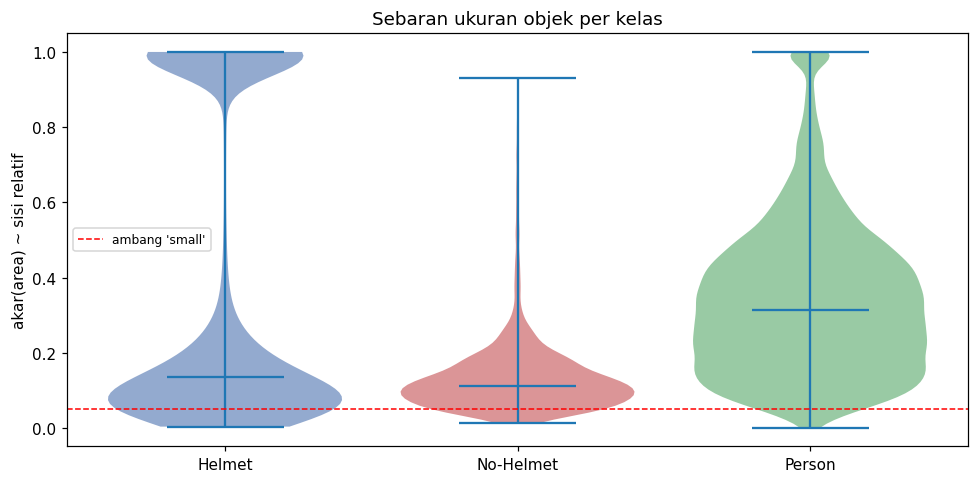

class
Helmet       0.01846
No-Helmet    0.01261
Person       0.09796
Name: median_area, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
data_by_class = [np.sqrt(df.loc[df.class_id == i, "area"].values) for i in range(nc)]
parts = ax.violinplot(data_by_class, showmedians=True, widths=0.8)
for pc, c in zip(parts["bodies"], COLORS): pc.set_facecolor(c); pc.set_alpha(0.6)
ax.set_xticks(range(1, nc+1)); ax.set_xticklabels(class_names)
ax.axhline(np.sqrt(SMALL), color="red", ls="--", lw=1, label="ambang 'small'")
ax.set_ylabel("akar(area) ~ sisi relatif"); ax.set_title("Sebaran ukuran objek per kelas")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
display(df.groupby("class")["area"].median().reindex(class_names).round(5).rename("median_area"))

## 5. Bentuk & rasio aspek bbox — *kenapa* augmentasi harus hati-hati
**💡** Klaster bentuk rapi memudahkan detektor; bentuk sangat bervariasi butuh lebih banyak data. Memandu augmentasi (hindari distorsi aspek ekstrem).

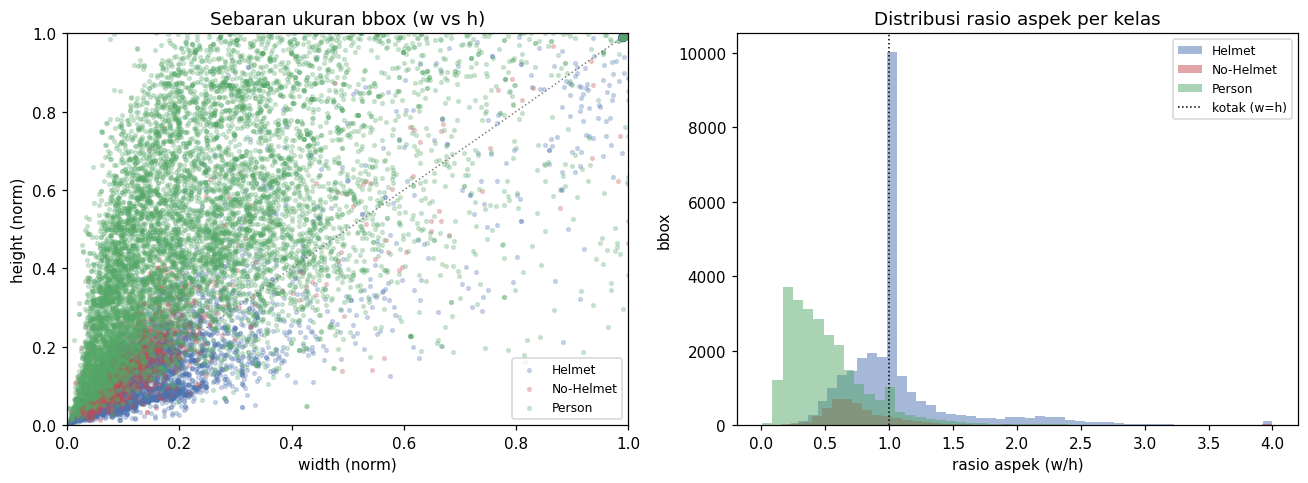

In [8]:
s = df.sample(min(20000, len(df)), random_state=42)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for i in range(nc):
    sub = s[s.class_id == i]
    ax[0].scatter(sub["w"], sub["h"], s=6, alpha=0.25, color=CLASS_COLORS[i], label=class_names[i])
ax[0].plot([0,1],[0,1], color="gray", ls=":", lw=1); ax[0].set_xlim(0,1); ax[0].set_ylim(0,1)
ax[0].set_xlabel("width (norm)"); ax[0].set_ylabel("height (norm)")
ax[0].set_title("Sebaran ukuran bbox (w vs h)"); ax[0].legend(fontsize=8)
for i in range(nc):
    ax[1].hist(np.clip(df.loc[df.class_id == i, "aspect"].values, 0, 4), bins=50, alpha=0.5,
               color=CLASS_COLORS[i], label=class_names[i])
ax[1].axvline(1.0, color="black", ls=":", lw=1, label="kotak (w=h)")
ax[1].set_xlabel("rasio aspek (w/h)"); ax[1].set_ylabel("bbox"); ax[1].set_title("Distribusi rasio aspek per kelas")
ax[1].legend(fontsize=8); plt.tight_layout(); plt.show()

## 6. Peta panas posisi objek — *kenapa* objek terkonsentrasi di area tertentu
**💡** Bias posisi (helm di atas, orang di tengah) dipelajari model. Beda pola posisi di test bisa menurunkan performa; memandu augmentasi crop.

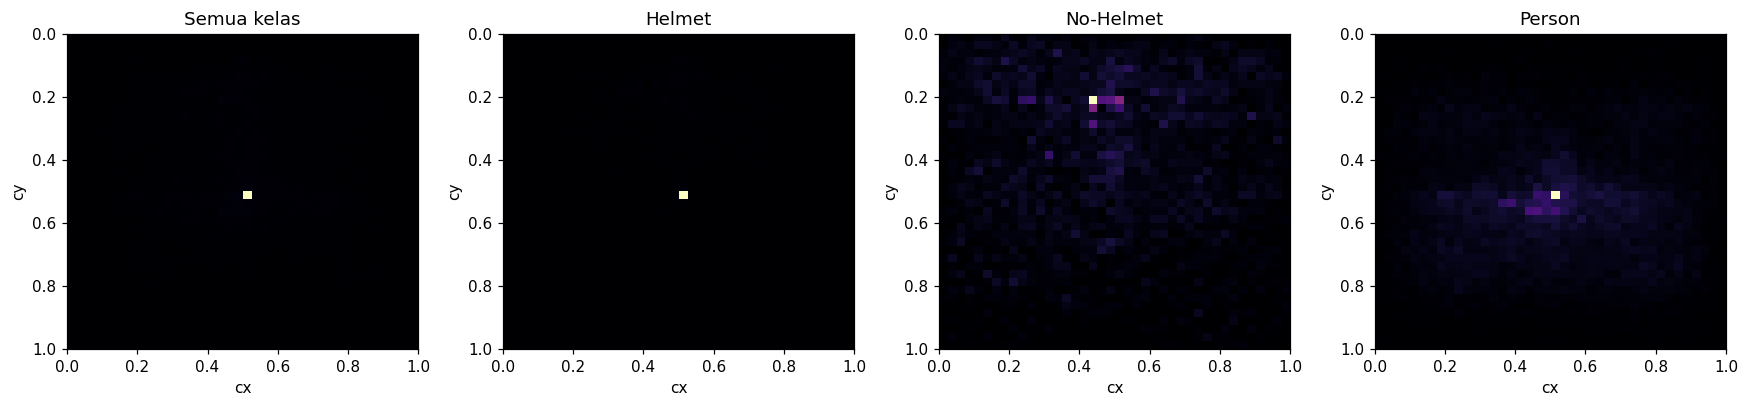

Sumbu-y dibalik (atas=0). Area terang = sering ada objek.


In [9]:
fig, axes = plt.subplots(1, nc+1, figsize=(4*(nc+1), 3.8))
def heat(ax, sub, title):
    H, _, _ = np.histogram2d(sub["cx"], sub["cy"], bins=40, range=[[0,1],[0,1]])
    ax.imshow(H.T, origin="upper", extent=[0,1,1,0], aspect="auto", cmap="magma")
    ax.set_title(title); ax.set_xlabel("cx"); ax.set_ylabel("cy")
heat(axes[0], df, "Semua kelas")
for i in range(nc): heat(axes[i+1], df[df.class_id == i], class_names[i])
plt.tight_layout(); plt.show()
print("Sumbu-y dibalik (atas=0). Area terang = sering ada objek.")

## 7. Kepadatan objek per gambar — *kenapa* `iou`/NMS & gambar padat penting
**💡** Gambar padat → kotak bertumpuk → ambang **NMS (`iou`)** berpengaruh. Gambar tanpa anotasi berguna sebagai contoh *background*.

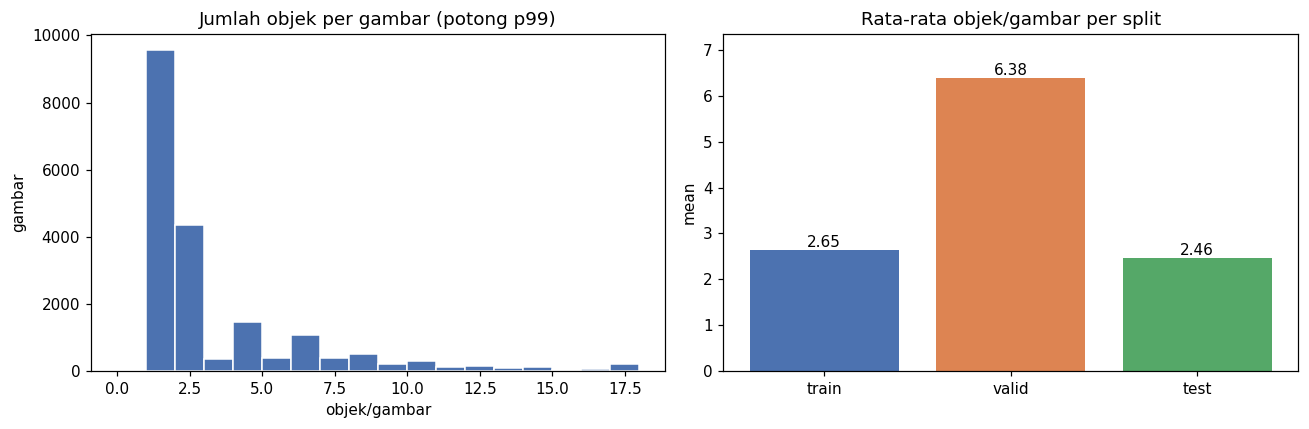

tanpa anotasi: 0.0%  |  max objek/gambar: 64


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
up = int(np.percentile(dens["n_boxes"], 99)) + 1
ax[0].hist(np.clip(dens["n_boxes"], 0, up), bins=range(0, max(up,2)+1), color="#4c72b0", edgecolor="white")
ax[0].set_title("Jumlah objek per gambar (potong p99)"); ax[0].set_xlabel("objek/gambar"); ax[0].set_ylabel("gambar")
by = dens.groupby("split")["n_boxes"].mean().reindex(["train","valid","test"])
b = ax[1].bar(by.index, by.values, color=["#4c72b0","#dd8452","#55a868"])
for bb, v in zip(b, by.values): ax[1].text(bb.get_x()+bb.get_width()/2, v, f"{v:.2f}", ha="center", va="bottom")
ax[1].set_title("Rata-rata objek/gambar per split"); ax[1].set_ylabel("mean"); ax[1].margins(y=0.15)
plt.tight_layout(); plt.show()
print(f"tanpa anotasi: {100*(dens['n_boxes']==0).mean():.1f}%  |  max objek/gambar: {dens['n_boxes'].max()}")

## 8. Resolusi & rasio aspek gambar — *kenapa* letterbox ke 640
**💡** Input beragam → YOLO **letterbox** (resize+padding) ke 640. Sebaran rasio aspek menjelaskan banyaknya padding & kenapa objek kecil bisa makin kecil.

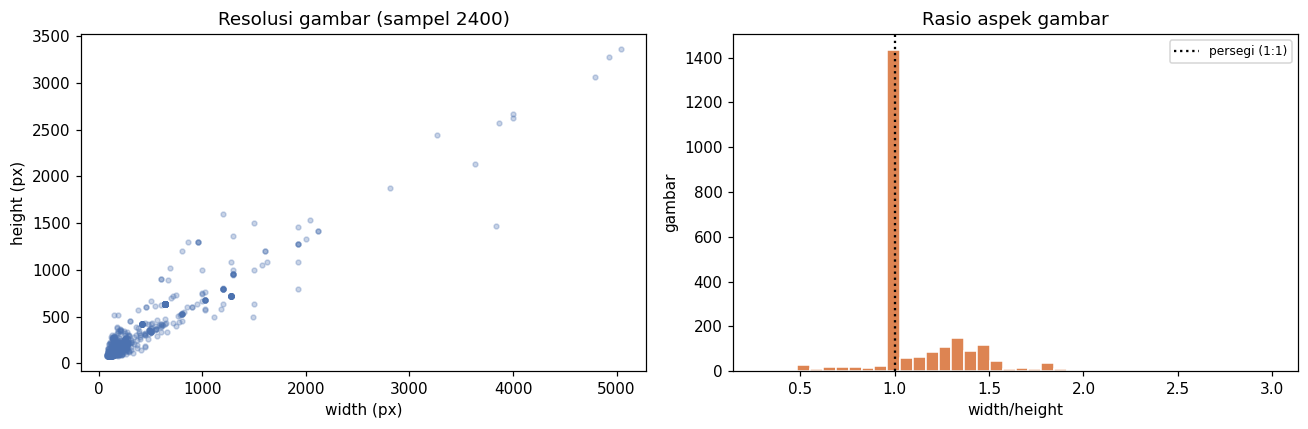

width median=640px  height median=640px


In [11]:
rng = np.random.default_rng(42)
sizes = []
for split, (images_dir, _) in splits.items():
    imgs = [p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    for k in rng.choice(len(imgs), size=min(800, len(imgs)), replace=False):
        try:
            with Image.open(imgs[int(k)]) as im: sizes.append(im.size)
        except Exception: pass
W = np.array([s[0] for s in sizes]); H = np.array([s[1] for s in sizes])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(W, H, s=10, alpha=0.3, color="#4c72b0"); ax[0].set_title(f"Resolusi gambar (sampel {len(sizes)})")
ax[0].set_xlabel("width (px)"); ax[0].set_ylabel("height (px)")
ax[1].hist(np.clip(W/H, 0, 3), bins=40, color="#dd8452", edgecolor="white")
ax[1].axvline(1.0, color="black", ls=":", label="persegi (1:1)"); ax[1].legend(fontsize=8)
ax[1].set_title("Rasio aspek gambar"); ax[1].set_xlabel("width/height"); ax[1].set_ylabel("gambar")
plt.tight_layout(); plt.show()
print(f"width median={int(np.median(W))}px  height median={int(np.median(H))}px")

## 9. Kualitas anotasi — *kenapa* sebagian label berisik *(BARU)*
**💡** Label **nyasar** (bukan 5-kolom), objek **sangat kecil**, objek **terpotong** di tepi, dan **duplikat** (IoU tinggi) semuanya menambah noise → menjelaskan sebagian kesalahan model dan kenapa beberapa label otomatis dibuang pipeline.

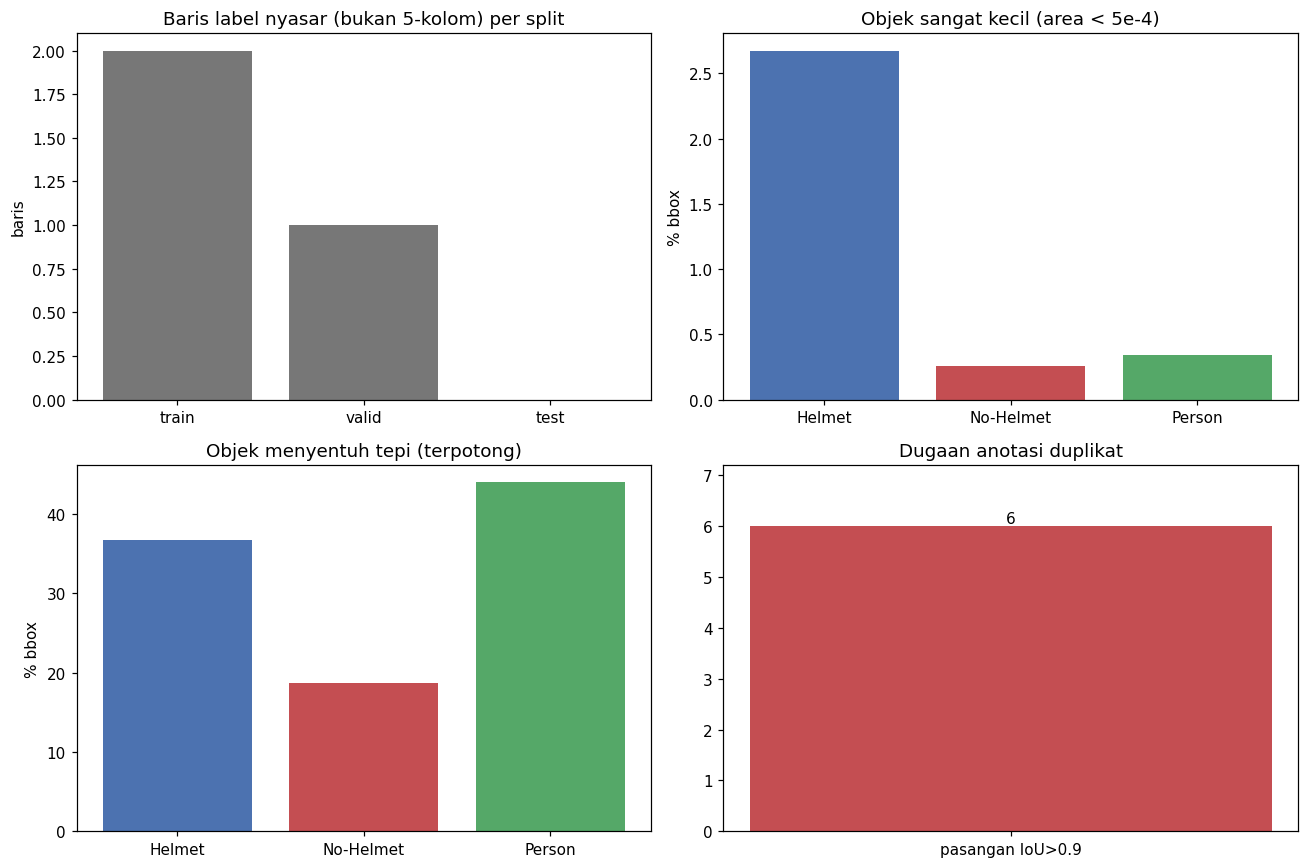

total label nyasar=3  tiny=845  terpotong=22,480  duplikat~6


In [12]:
def iou_xywh(a, b):
    ax1, ay1, ax2, ay2 = a[0]-a[2]/2, a[1]-a[3]/2, a[0]+a[2]/2, a[1]+a[3]/2
    bx1, by1, bx2, by2 = b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2
    iw = max(0, min(ax2,bx2)-max(ax1,bx1)); ih = max(0, min(ay2,by2)-max(ay1,by1))
    inter = iw*ih; ua = a[2]*a[3]+b[2]*b[3]-inter
    return inter/ua if ua > 0 else 0.0
dup = 0
for _, g in df.groupby(["split", "stem", "class_id"]):
    arr = g[["cx","cy","w","h"]].values
    for i in range(len(arr)):
        for j in range(i+1, len(arr)):
            if iou_xywh(arr[i], arr[j]) > 0.9: dup += 1

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
sp = list(malformed_by_split)
ax[0,0].bar(sp, [malformed_by_split[s] for s in sp], color="#777")
ax[0,0].set_title("Baris label nyasar (bukan 5-kolom) per split"); ax[0,0].set_ylabel("baris")
tf = [100*df[df.class_id==i]["tiny"].mean() for i in range(nc)]
ax[0,1].bar(class_names, tf, color=COLORS); ax[0,1].set_title("Objek sangat kecil (area < 5e-4)"); ax[0,1].set_ylabel("% bbox")
ef = [100*df[df.class_id==i]["edge"].mean() for i in range(nc)]
ax[1,0].bar(class_names, ef, color=COLORS); ax[1,0].set_title("Objek menyentuh tepi (terpotong)"); ax[1,0].set_ylabel("% bbox")
ax[1,1].bar(["pasangan IoU>0.9"], [dup], color="#c44e52"); ax[1,1].set_title("Dugaan anotasi duplikat")
ax[1,1].text(0, dup, f"{dup:,}", ha="center", va="bottom"); ax[1,1].margins(y=0.2)
plt.tight_layout(); plt.show()
print(f"total label nyasar={sum(malformed_by_split.values()):,}  tiny={int(df['tiny'].sum()):,}  "
      f"terpotong={int(df['edge'].sum()):,}  duplikat~{dup:,}")

## 10. Perbandingan kesulitan antar split — *kenapa* val/test bisa lebih sulit *(BARU)*
**💡** Bila objek di test lebih **kecil** atau gambar lebih **padat** daripada train, penurunan metrik di test sebagian **wajar** (bukan murni overfitting).

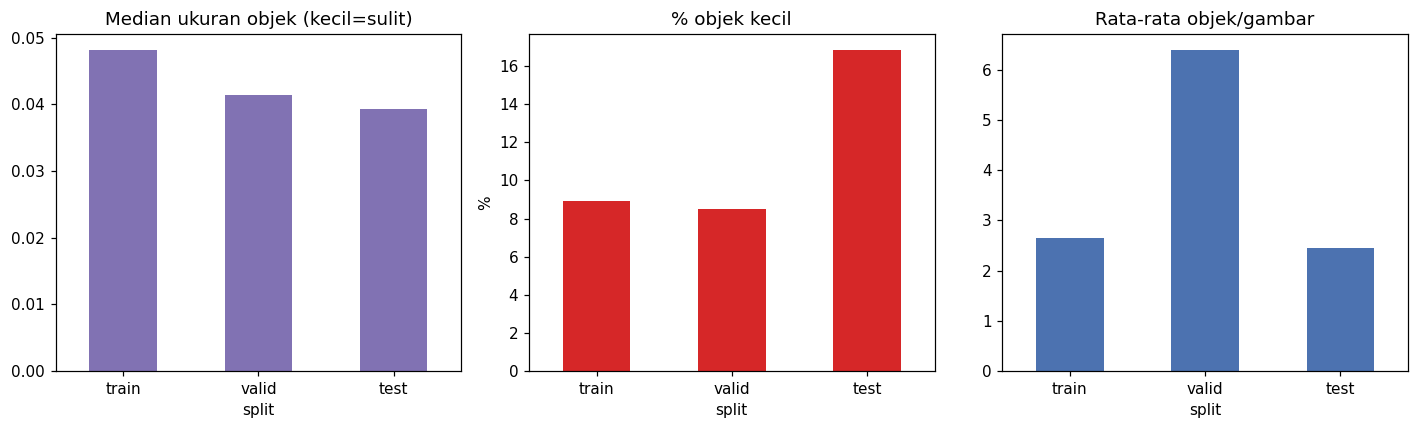

,median_area,pct_small,mean_density
split,,,
train,0.0481,8.9207,2.6451
valid,0.0415,8.5132,6.3835
test,0.0393,16.8271,2.4566


In [13]:
rows = []
for s in ["train", "valid", "test"]:
    d = df[df.split == s]; dd = dens[dens.split == s]
    rows.append([s, d["area"].median(), 100*(d["area"] < SMALL).mean(), dd["n_boxes"].mean()])
A = pd.DataFrame(rows, columns=["split","median_area","pct_small","mean_density"]).set_index("split")
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
A["median_area"].plot.bar(ax=ax[0], color="#8172b3"); ax[0].set_title("Median ukuran objek (kecil=sulit)")
A["pct_small"].plot.bar(ax=ax[1], color="#d62728"); ax[1].set_title("% objek kecil"); ax[1].set_ylabel("%")
A["mean_density"].plot.bar(ax=ax[2], color="#4c72b0"); ax[2].set_title("Rata-rata objek/gambar")
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show(); display(A.round(4))

## 11. Contoh anotasi nyata — *melihat* dari mana kesalahan berasal
**💡** Melihat kotak asli mengungkap kualitas anotasi, oklusi, dan kemiripan antar kelas (helm vs kepala) — sumber error model.

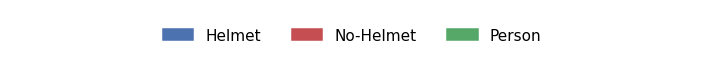

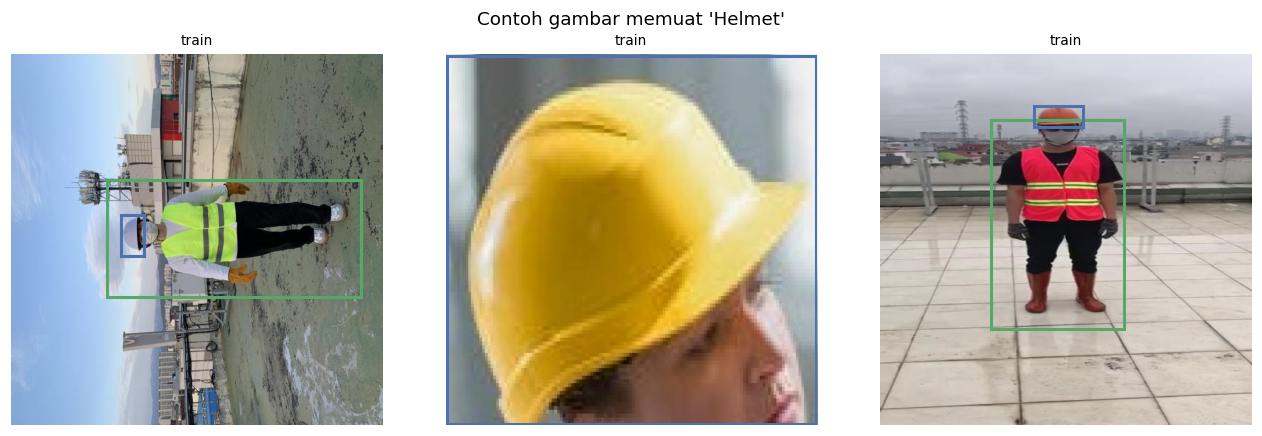

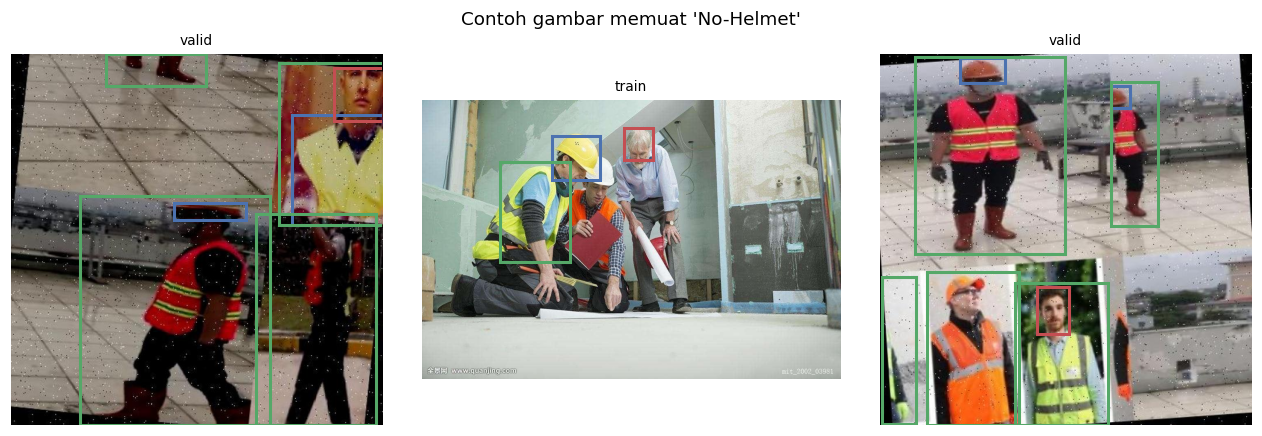

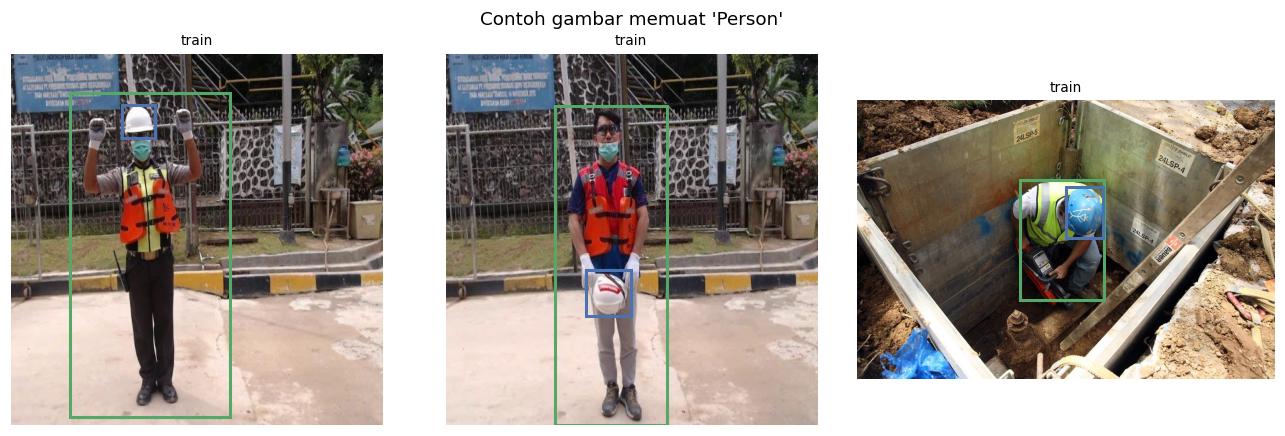

In [14]:
def draw_examples(cid, k=3):
    rows = df[df.class_id == cid][["split","stem"]].drop_duplicates().sample(min(k, len(df[df.class_id==cid])), random_state=7)
    fig, axes = plt.subplots(1, k, figsize=(4*k, 4)); axes = np.atleast_1d(axes)
    for ax, (_, r) in zip(axes, rows.iterrows()):
        path = path_map.get((r["split"], r["stem"]))
        if path is None or not path.exists(): ax.axis("off"); continue
        with Image.open(path) as im:
            im = im.convert("RGB"); W, H = im.size; ax.imshow(im)
        for _, bb in df[(df["split"]==r["split"]) & (df["stem"]==r["stem"])].iterrows():
            x = (bb["cx"]-bb["w"]/2)*W; y = (bb["cy"]-bb["h"]/2)*H
            ax.add_patch(mpatches.Rectangle((x, y), bb["w"]*W, bb["h"]*H, fill=False,
                         edgecolor=CLASS_COLORS[int(bb["class_id"])], lw=2))
        ax.set_title(r["split"], fontsize=9); ax.axis("off")
    fig.suptitle(f"Contoh gambar memuat '{class_names[cid]}'", fontsize=12); plt.tight_layout(); plt.show()
legend = [mpatches.Patch(color=CLASS_COLORS[i], label=class_names[i]) for i in range(nc)]
plt.figure(figsize=(8, 0.6)); plt.legend(handles=legend, ncol=nc, loc="center", frameon=False); plt.axis("off"); plt.show()
for cid in range(nc): draw_examples(cid, 3)

## 12. Ko-okurensi kelas — *kenapa* `Person` & `Helmet` saling terkait
**💡** Orang **memakai** helm → konteks saling bantu, tapi juga sumber kebingungan Helmet↔No-Helmet pada orang yang sama.

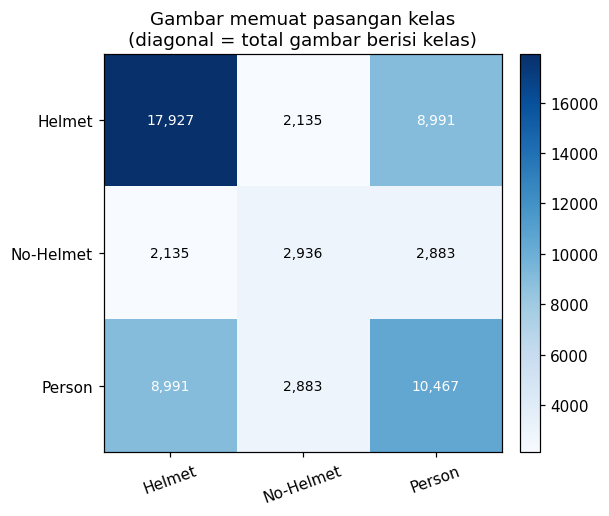

In [15]:
M = np.zeros((nc, nc), dtype=int)
for _, g in df.groupby(["split", "stem"]):
    cs = sorted(set(g["class_id"]))
    for i in cs:
        for j in cs: M[i, j] += 1
fig, ax = plt.subplots(figsize=(5.5, 4.8)); im = ax.imshow(M, cmap="Blues")
ax.set_xticks(range(nc)); ax.set_xticklabels(class_names, rotation=20)
ax.set_yticks(range(nc)); ax.set_yticklabels(class_names)
for i in range(nc):
    for j in range(nc):
        ax.text(j, i, f"{M[i,j]:,}", ha="center", va="center",
                color="white" if M[i,j] > M.max()*0.5 else "black", fontsize=9)
ax.set_title("Gambar memuat pasangan kelas\n(diagonal = total gambar berisi kelas)")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 13. Kebocoran data antar-split (near-duplicate) — *kenapa* metrik bisa optimistis *(BARU)*
**❓** Adakah gambar di valid/test yang **sama/mirip** dengan train?

**💡 Mengapa penting:** export Roboflow + augmentasi sering membuat **leakage**. Kalau val/test mengandung duplikat train, metrik jadi **terlalu bagus** dan tidak mencerminkan performa sebenarnya. Dideteksi via *perceptual hash* (aHash 8×8) + jarak Hamming.

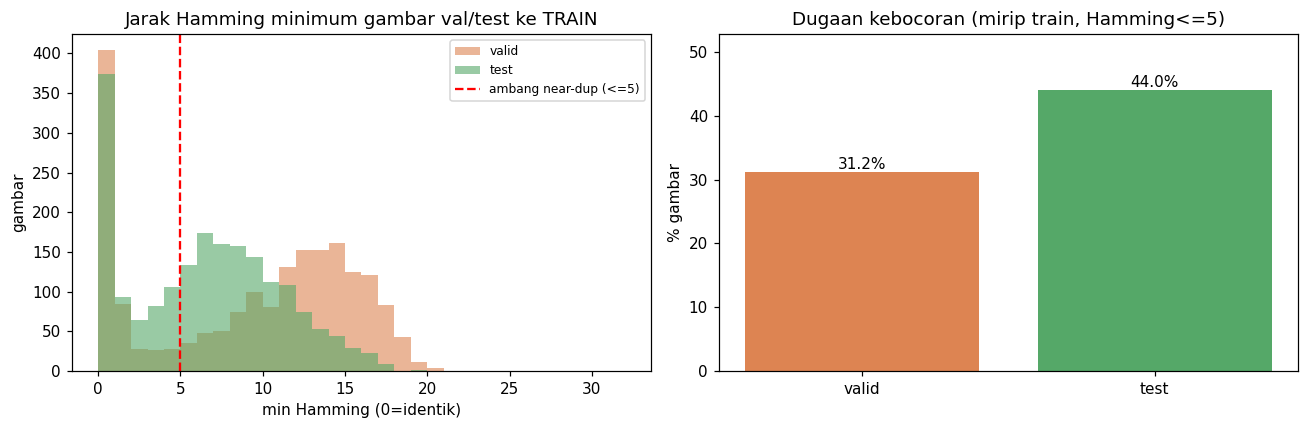

Near-duplicate ke train  ->  valid: 31.2%   test: 44.0%   (sampel train=4000)


In [16]:
def ahash(path, size=8):
    try:
        with Image.open(path) as im:
            g = np.asarray(im.convert("L").resize((size, size)), dtype=np.float32)
    except Exception:
        return None
    return (g > g.mean()).astype(np.uint8).flatten()

rng = np.random.default_rng(0)
hashes, hpaths = {}, {}
for split, (images_dir, _) in splits.items():
    imgs = [p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    if split == "train" and len(imgs) > 4000:
        imgs = [imgs[i] for i in rng.choice(len(imgs), 4000, replace=False)]
    bl, pl = [], []
    for p in imgs:
        b = ahash(p)
        if b is not None:
            bl.append(b); pl.append(p)
    hashes[split] = np.array(bl) if bl else np.zeros((0, 64), np.uint8)
    hpaths[split] = pl
train_bits = hashes.get("train", np.zeros((0, 64), np.uint8))

def min_hamming(bits_set):
    out = []
    for b in bits_set:
        out.append(64 if len(train_bits) == 0 else int((train_bits ^ b).sum(axis=1).min()))
    return np.array(out)
dmin = {s: min_hamming(hashes.get(s, [])) for s in ("valid", "test")}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for s, c in [("valid", "#dd8452"), ("test", "#55a868")]:
    if len(dmin[s]):
        ax[0].hist(dmin[s], bins=range(0, 33), color=c, alpha=0.6, label=s)
ax[0].axvline(5, color="red", ls="--", label="ambang near-dup (<=5)")
ax[0].set_title("Jarak Hamming minimum gambar val/test ke TRAIN")
ax[0].set_xlabel("min Hamming (0=identik)"); ax[0].set_ylabel("gambar"); ax[0].legend(fontsize=8)
leak = {s: (100*(dmin[s] <= 5).mean() if len(dmin[s]) else 0.0) for s in ("valid", "test")}
b = ax[1].bar(list(leak), list(leak.values()), color=["#dd8452", "#55a868"])
for bb, v in zip(b, leak.values()): ax[1].text(bb.get_x()+bb.get_width()/2, v, f"{v:.1f}%", ha="center", va="bottom")
ax[1].set_title("Dugaan kebocoran (mirip train, Hamming<=5)"); ax[1].set_ylabel("% gambar"); ax[1].margins(y=0.2)
plt.tight_layout(); plt.show()
print(f"Near-duplicate ke train  ->  valid: {leak['valid']:.1f}%   test: {leak['test']:.1f}%   (sampel train={len(train_bits)})")

Beberapa pasangan **paling mirip** (val/test ↔ train) untuk diperiksa mata:

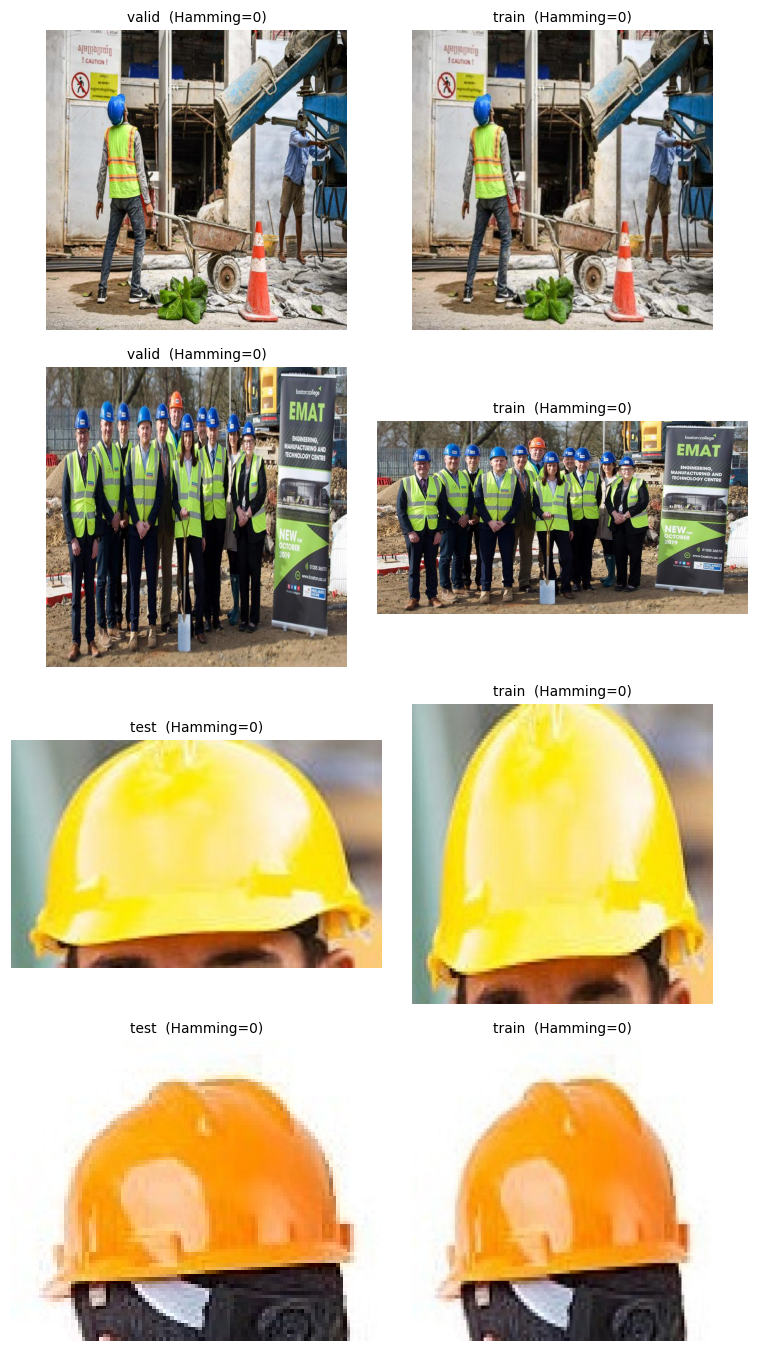

=> Hamming kecil = kemungkinan duplikat. Jika banyak, pisahkan ulang split agar evaluasi jujur.


In [17]:
pairs = []
for s in ("valid", "test"):
    if not len(dmin[s]): continue
    for k in np.argsort(dmin[s])[:2]:
        b = hashes[s][k]; d = (train_bits ^ b).sum(axis=1)
        pairs.append((hpaths[s][int(k)], hpaths["train"][int(d.argmin())], int(d.min()), s))
if pairs:
    fig, axes = plt.subplots(len(pairs), 2, figsize=(7, 3.1*len(pairs))); axes = np.atleast_2d(axes)
    for r, (pq, pt, dist, s) in enumerate(pairs):
        for col, (p, lab) in enumerate([(pq, s), (pt, "train")]):
            try: axes[r, col].imshow(Image.open(p).convert("RGB"))
            except Exception: pass
            axes[r, col].set_title(f"{lab}  (Hamming={dist})", fontsize=9); axes[r, col].axis("off")
    plt.tight_layout(); plt.show()
print("=> Hamming kecil = kemungkinan duplikat. Jika banyak, pisahkan ulang split agar evaluasi jujur.")

## 14. Kualitas gambar: kecerahan & blur — *kenapa* model gagal di kondisi nyata *(BARU)*
**❓** Seberapa banyak gambar gelap/terlalu terang/blur?

**💡 Mengapa penting:** banyak file berasal dari **frame video** (`Video*`, `mp4`) → motion blur & low-light. Ini sumber kegagalan nyata di lapangan dan menjelaskan sebagian False Negative.

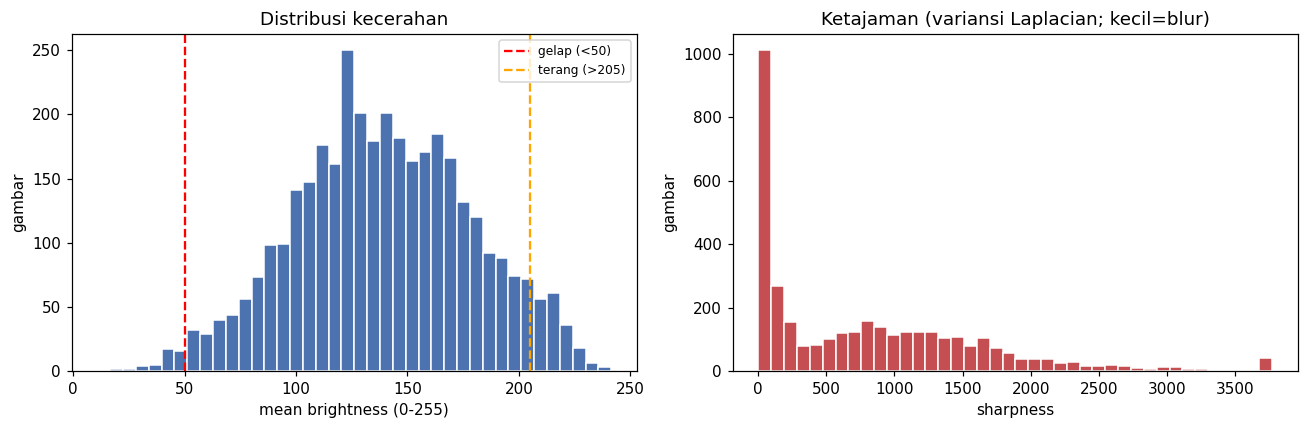

gelap (<50): 1.2%   terang (>205): 5.6%   blur (sharpness<p10): 10.0%


In [18]:
def lap_var(g):
    k = g[1:-1, 1:-1]
    lap = g[:-2, 1:-1] + g[2:, 1:-1] + g[1:-1, :-2] + g[1:-1, 2:] - 4*k
    return float(lap.var())
rng = np.random.default_rng(1)
rows, qpaths = [], []
for split, (images_dir, _) in splits.items():
    imgs = [p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS]
    for i in rng.choice(len(imgs), size=min(1200, len(imgs)), replace=False):
        p = imgs[int(i)]
        try:
            with Image.open(p) as im:
                g = np.asarray(im.convert("L").resize((256, 256)), dtype=np.float32)
        except Exception:
            continue
        rows.append((split, float(g.mean()), lap_var(g))); qpaths.append(p)
Q = pd.DataFrame(rows, columns=["split", "brightness", "sharpness"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(Q["brightness"], bins=40, color="#4c72b0", edgecolor="white")
ax[0].axvline(50, color="red", ls="--", label="gelap (<50)"); ax[0].axvline(205, color="orange", ls="--", label="terang (>205)")
ax[0].set_title("Distribusi kecerahan"); ax[0].set_xlabel("mean brightness (0-255)"); ax[0].set_ylabel("gambar"); ax[0].legend(fontsize=8)
ax[1].hist(np.clip(Q["sharpness"], 0, np.percentile(Q["sharpness"], 99)), bins=40, color="#c44e52", edgecolor="white")
ax[1].set_title("Ketajaman (variansi Laplacian; kecil=blur)"); ax[1].set_xlabel("sharpness"); ax[1].set_ylabel("gambar")
plt.tight_layout(); plt.show()
print(f"gelap (<50): {100*(Q.brightness<50).mean():.1f}%   terang (>205): {100*(Q.brightness>205).mean():.1f}%   "
      f"blur (sharpness<p10): {100*(Q.sharpness<Q.sharpness.quantile(0.10)).mean():.1f}%")

Montase gambar **paling gelap** & **paling blur** (kondisi nyata yang menyulitkan model):

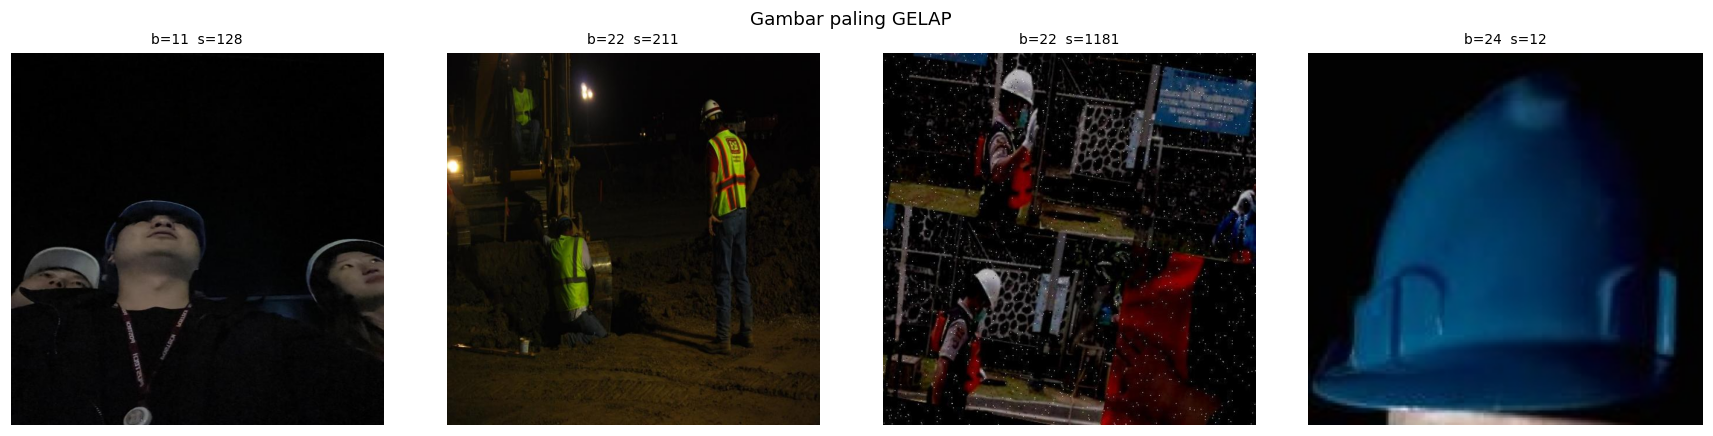

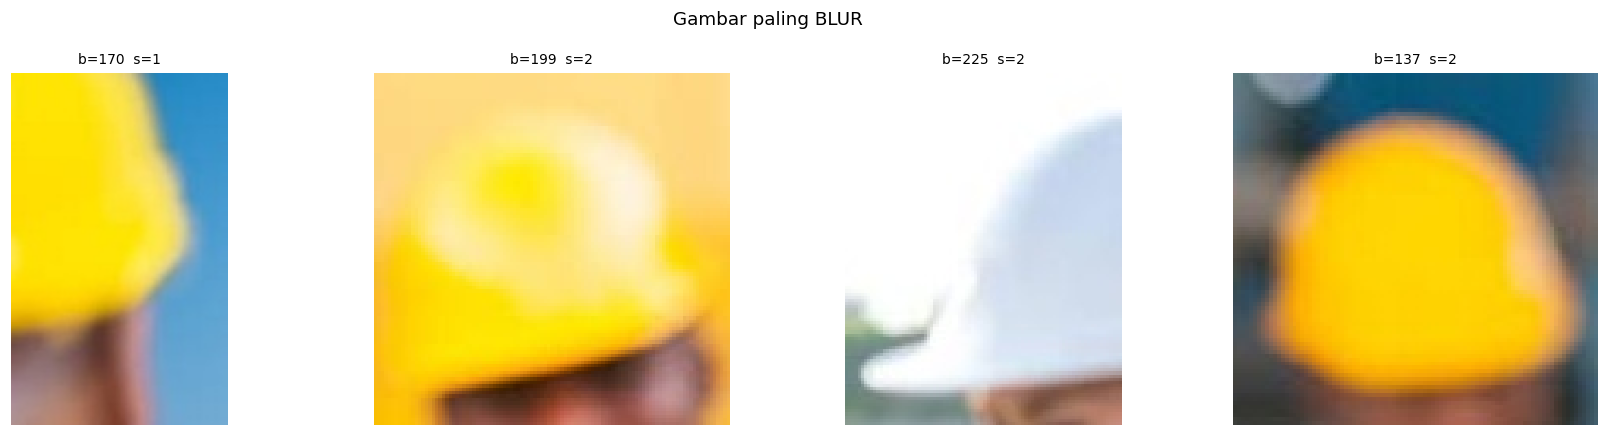

=> Gambar gelap/blur ini realistis untuk lokasi konstruksi; pertimbangkan augmentasi brightness/blur.


In [19]:
def montage_q(title, idxs):
    idxs = list(idxs)[:4]
    if not idxs: return
    fig, axes = plt.subplots(1, len(idxs), figsize=(4*len(idxs), 4)); axes = np.atleast_1d(axes)
    for ax, j in zip(axes, idxs):
        try: ax.imshow(Image.open(qpaths[j]).convert("RGB"))
        except Exception: pass
        ax.set_title(f"b={Q.brightness[j]:.0f}  s={Q.sharpness[j]:.0f}", fontsize=9); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()
montage_q("Gambar paling GELAP", Q.brightness.nsmallest(4).index)
montage_q("Gambar paling BLUR", Q.sharpness.nsmallest(4).index)
print("=> Gambar gelap/blur ini realistis untuk lokasi konstruksi; pertimbangkan augmentasi brightness/blur.")

## 15. Asal-usul data dari pola nama file — *kenapa* dataset heterogen *(BARU)*
**❓** Dari sumber apa saja gambar ini berasal?

**💡 Mengapa penting:** nama file mengungkap **campuran beberapa sumber** (`ppe_*`, `Video*`, `image_*`, hash). Domain berbeda → relevan untuk generalisasi dan menjelaskan keragaman kualitas/komposisi kelas.

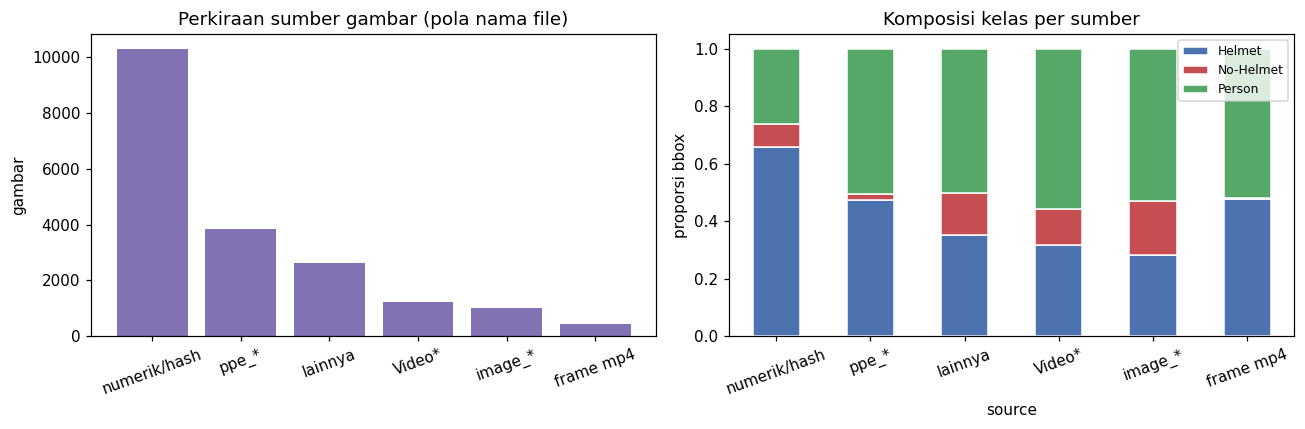

=> Dataset campuran beberapa sumber => domain beragam (relevan untuk generalisasi).


In [20]:
import re
def source_of(stem):
    s = str(stem).lower()
    if s.startswith("ppe_"): return "ppe_*"
    if s.startswith("video"): return "Video*"
    if s.startswith("image_"): return "image_*"
    if "mp4" in s: return "frame mp4"
    if re.match(r"^\d", s): return "numerik/hash"
    return "lainnya"
imgsrc = df.drop_duplicates(["split", "stem"]).copy()
imgsrc["source"] = imgsrc["stem"].map(source_of)
cnt = imgsrc["source"].value_counts()
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(cnt.index, cnt.values, color="#8172b3"); ax[0].set_title("Perkiraan sumber gambar (pola nama file)")
ax[0].set_ylabel("gambar"); ax[0].tick_params(axis="x", rotation=20)
cc = pd.crosstab(df.assign(source=df["stem"].map(source_of))["source"], df["class"]).reindex(cnt.index)
cc.div(cc.sum(axis=1), axis=0)[class_names].plot.bar(stacked=True, ax=ax[1], color=COLORS, edgecolor="white")
ax[1].set_title("Komposisi kelas per sumber"); ax[1].set_ylabel("proporsi bbox"); ax[1].tick_params(axis="x", rotation=20); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("=> Dataset campuran beberapa sumber => domain beragam (relevan untuk generalisasi).")

## 16. Adegan campuran Helmet + No-Helmet — *kenapa* ini skenario K3 paling kritis *(BARU)*
**❓** Berapa gambar yang memuat pekerja berhelm **dan** tanpa helm sekaligus?

**💡 Mengapa penting:** justru di adegan campuran inilah deteksi `No-Helmet` paling bernilai (pelanggaran K3) **dan** paling rawan tertukar dengan `Helmet`.

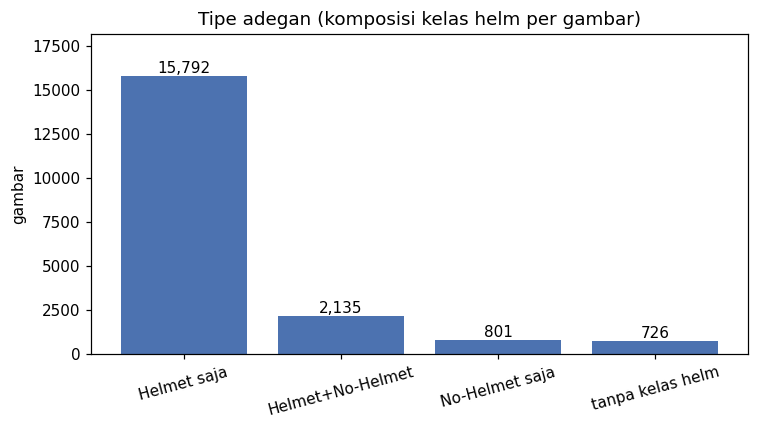

Adegan Helmet+No-Helmet: 2,135 gambar (11.0% gambar beranotasi)


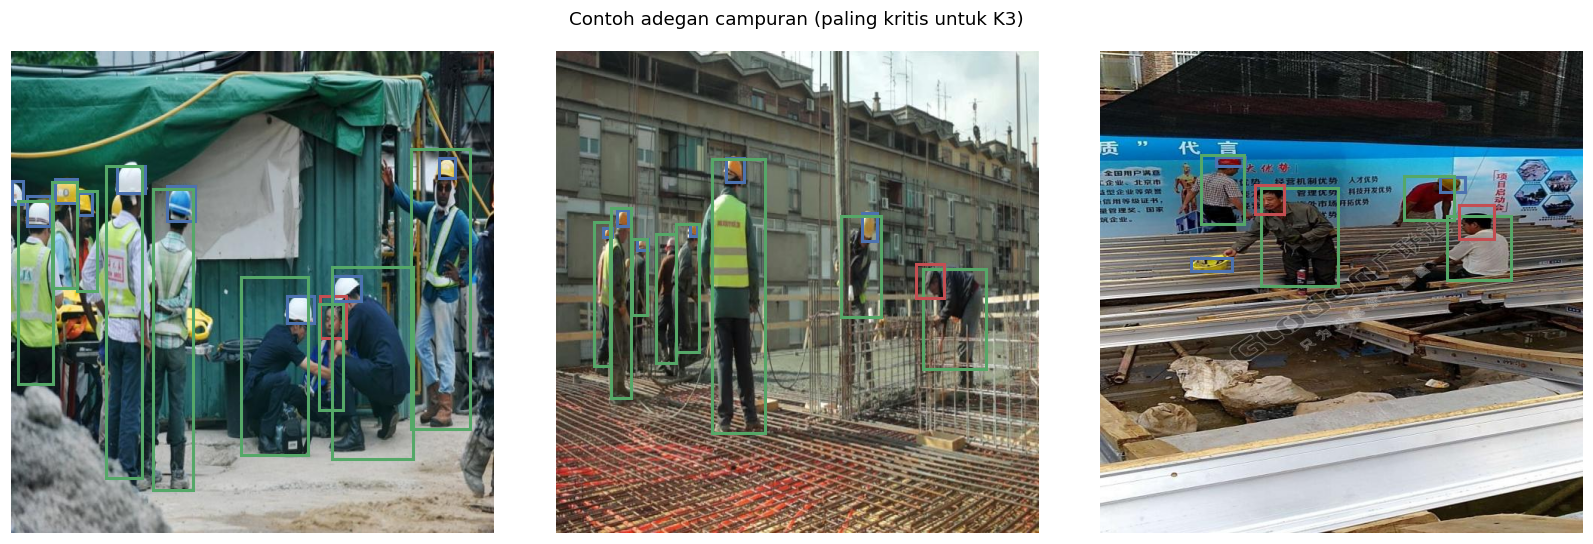

In [21]:
by_img = df.groupby(["split", "stem"])["class_id"].apply(set)
def scene(s):
    h, nh = 0 in s, 1 in s
    if h and nh: return "Helmet+No-Helmet"
    if nh: return "No-Helmet saja"
    if h: return "Helmet saja"
    return "tanpa kelas helm"
sc = by_img.apply(scene).value_counts()
both = [k for k, v in by_img.items() if (0 in v) and (1 in v)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sc.index, sc.values, color="#4c72b0")
for i, v in enumerate(sc.values): ax.text(i, v, f"{v:,}", ha="center", va="bottom")
ax.set_title("Tipe adegan (komposisi kelas helm per gambar)"); ax.set_ylabel("gambar"); ax.tick_params(axis="x", rotation=15); ax.margins(y=0.15)
plt.tight_layout(); plt.show()
print(f"Adegan Helmet+No-Helmet: {len(both):,} gambar ({100*len(both)/len(by_img):.1f}% gambar beranotasi)")
if both:
    ex = both[:3]
    fig, axes = plt.subplots(1, len(ex), figsize=(5*len(ex), 5)); axes = np.atleast_1d(axes)
    for ax, (split, stem) in zip(axes, ex):
        p = path_map.get((split, stem))
        if p:
            with Image.open(p) as im:
                im = im.convert("RGB"); W, H = im.size; ax.imshow(im)
            for _, bb in df[(df.split == split) & (df.stem == stem)].iterrows():
                x = (bb.cx-bb.w/2)*W; y = (bb.cy-bb.h/2)*H
                ax.add_patch(mpatches.Rectangle((x, y), bb.w*W, bb.h*H, fill=False, edgecolor=CLASS_COLORS[int(bb.class_id)], lw=2))
        ax.axis("off")
    fig.suptitle("Contoh adegan campuran (paling kritis untuk K3)"); plt.tight_layout(); plt.show()

## 17. Konsentrasi spasial objek kecil — *kenapa* `imgsz=640` & crop hati-hati *(BARU)*
**❓** Di mana objek kecil berkumpul?

**💡 Mengapa penting:** kalau objek kecil terkonsentrasi (mis. pekerja jauh di dekat horizon), menurunkan resolusi/crop area itu langsung menghapusnya → memperkuat alasan mempertahankan 640.

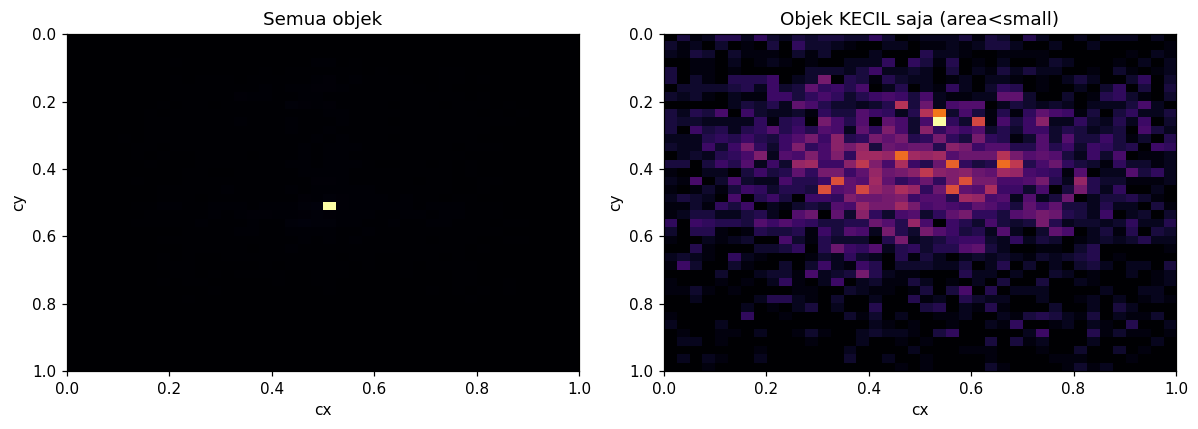

objek kecil = 9.5% bbox. Bandingkan pola sebarannya dgn semua objek.


In [22]:
small = df[df.area < SMALL]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (sub, title) in zip(ax, [(df, "Semua objek"), (small, "Objek KECIL saja (area<small)")]):
    H, _, _ = np.histogram2d(sub.cx, sub.cy, bins=40, range=[[0, 1], [0, 1]])
    a.imshow(H.T, origin="upper", extent=[0, 1, 1, 0], aspect="auto", cmap="inferno")
    a.set_title(title); a.set_xlabel("cx"); a.set_ylabel("cy")
plt.tight_layout(); plt.show()
print(f"objek kecil = {100*(df.area < SMALL).mean():.1f}% bbox. Bandingkan pola sebarannya dgn semua objek.")

## 18. Tulis artefak resmi ke `runs/eda/`
Menulis CSV + report + 6 figur standar (sama seperti menjalankan `python src/eda.py`) untuk paritas dengan pipeline.

In [23]:
import contextlib
with open(os.devnull, "w", encoding="utf-8") as _n, contextlib.redirect_stderr(_n):
    result = eda.run_eda("dataset/data.yaml", out_dir="runs/eda", img_sample=800, make_plots=True)
print("artefak tertulis di runs/eda/: eda_summary.csv, class_distribution.csv, "
      "bbox_statistics.csv, image_statistics.csv, eda_report.txt, figures/*.png")

artefak tertulis di runs/eda/: eda_summary.csv, class_distribution.csv, bbox_statistics.csv, image_statistics.csv, eda_report.txt, figures/*.png


## 🧭 Ringkasan: visual mana mendukung keputusan apa

| Keputusan | Didukung oleh |
|---|---|
| `imgsz=640` dipertahankan | §3, §8 (objek kecil + letterbox) |
| Pantau recall `No-Helmet` | §1, §2, §4 |
| `iou`/NMS default penting | §7 |
| Augmentasi hati-hati | §5, §6 |
| Evaluasi val *dan* test terpisah | §2, §10 |
| Sebagian label perlu dibersihkan | §9 |
| Kebingungan Helmet↔No-Helmet | §11, §12 |